In [3]:
import glob
import gc
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


DIR = "/../../orcd/pool/003/dbertsim_shared/ukb/"

In [10]:
def clean_chrom(path, chrom):
    df = pd.read_parquet(path)
    df = df.fillna(-1)
    df = df.loc[df['sample_idx'].isin(sample_map['sample_idx'])]
    df_pivot = df.pivot(index='sample_idx', columns='variant_idx', values='dosage')
    df_pivot = df_pivot.fillna(0)
    df_pivot = df_pivot.replace(-1,np.NaN) 
    df_pivot = df_pivot.add_prefix(f"c{chrom}_").reset_index()
    df_pivot = pd.merge(sample_map, df_pivot, on = 'sample_idx', how = 'left')

    return df_pivot

def variant_missingness_distribution(chrom, save_prefix=None):
    # Adjust the glob to match your actual file names/paths
    files = sorted(
        glob.glob(f"{DIR}bgen/ch{chrom}/c{chrom}_b0_*parquet")
    )
    print(f"Found {len(files)} files for chromosome {chrom}")

    chrom_str = str(chrom)
    is_Y = chrom_str.upper() == "Y"

    all_missing_fracs = []
    all_zero_fracs = []
    all_one_fracs = []
    all_two_fracs = []

    for path in files:
        filename = Path(path).stem
        df = clean_chrom(path, chrom)  # must return 'eid' + variant columns

        # keep only variant columns; adjust prefix if needed
        X = df.loc[:, df.columns.str.startswith(f"c{chrom}_")]

        # print(f"{filename}: {len(df)} rows, {X.shape[1]} variant cols")

        if X.shape[1] == 0 or len(df) == 0:
            del df, X
            gc.collect()
            continue

        # fraction of missing / 0 / 1 mutation / 2 mutations per variant
        missing_frac = X.isna().mean(axis=0).to_numpy()
        zero_frac = (X == 0).mean(axis=0).to_numpy()
        one_frac = (X == 1).mean(axis=0).to_numpy()
        two_frac = (X == 2).mean(axis=0).to_numpy()

        all_missing_fracs.append(missing_frac)
        all_zero_fracs.append(zero_frac)
        all_one_fracs.append(one_frac)
        all_two_fracs.append(two_frac)

        del df, X
        gc.collect()

    if not all_missing_fracs:
        print("No data after filtering on eids.")
        return None

    all_missing_fracs = np.concatenate(all_missing_fracs)
    all_zero_fracs = np.concatenate(all_zero_fracs)
    all_one_fracs = np.concatenate(all_one_fracs)
    all_two_fracs = np.concatenate(all_two_fracs)

    n_variants = len(all_missing_fracs)

    # 0–0.1, 0.1–0.2, ..., 0.9–1.0
    bins = np.linspace(0, 1, 11)
    counts_missing, edges = np.histogram(all_missing_fracs, bins=bins)
    counts_zero, _ = np.histogram(all_zero_fracs, bins=bins)
    counts_one, _ = np.histogram(all_one_fracs, bins=bins)
    counts_two, _ = np.histogram(all_two_fracs, bins=bins)

    prop_missing = counts_missing / n_variants
    prop_zero = counts_zero / n_variants
    prop_one = counts_one / n_variants
    prop_two = counts_two / n_variants

    x = np.arange(len(edges) - 1)
    width = 0.6

    # Plot 1: missingness only (uniform 0.1 buckets)
    fig, ax = plt.subplots(figsize=(9, 4))
    bars_missing = ax.bar(x, prop_missing, width, label="missing", edgecolor="k")
    ax.bar_label(bars_missing, labels=counts_missing)

    ax.set_xlabel("Missingness fraction range")
    ax.set_ylabel("Proportion of variants")
    ax.set_title(f"Variant missingness distribution – chromosome {chrom}")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{edges[i]:.1f}-{edges[i+1]:.1f}" for i in range(len(edges) - 1)], rotation=45)
    ax.legend()

    plt.tight_layout()
    if save_prefix:
        fig.savefig(f"{save_prefix}_missingness.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Plot 2: mutations only — separate 0-mutation bucket, then quantile buckets for variants with mutation > 0
    if is_Y:
        has_zero_mut = all_one_fracs == 0
    else:
        has_zero_mut = (all_one_fracs == 0) & (all_two_fracs == 0)
    n_zero_mut = int(has_zero_mut.sum())
    mask_pos = ~has_zero_mut
    n_pos = mask_pos.sum()

    if is_Y:
        mut_fracs_pos = all_one_fracs[mask_pos]
    else:
        mut_fracs_pos = np.concatenate([all_one_fracs[mask_pos], all_two_fracs[mask_pos]])
    max_mut = mut_fracs_pos.max() if mut_fracs_pos.size > 0 else 0.0

    if max_mut > 0 and n_pos > 0:
        n_quantiles = 10
        qs = np.linspace(0, 1, n_quantiles + 1)
        raw_edges = np.quantile(mut_fracs_pos, qs)
        raw_edges[0] = mut_fracs_pos.min()
        raw_edges[-1] = max_mut
        edges_mut = np.unique(raw_edges)
        if edges_mut.size < 2:
            edges_mut = np.array([mut_fracs_pos.min(), max_mut])

        counts_one_mut, _ = np.histogram(all_one_fracs[mask_pos], bins=edges_mut)
        counts_zero_mut = np.zeros(len(edges_mut) - 1, dtype=int)
        if is_Y:
            counts_two_mut = None
        else:
            counts_two_mut, _ = np.histogram(all_two_fracs[mask_pos], bins=edges_mut)

        prop_zero_mut = np.concatenate([[n_zero_mut / n_variants], counts_zero_mut / n_variants])
        prop_one_mut = np.concatenate([[0.0], counts_one_mut / n_variants])
        if is_Y:
            prop_two_mut = None
        else:
            prop_two_mut = np.concatenate([[0.0], counts_two_mut / n_variants])
        counts_zero_display = np.concatenate([[n_zero_mut], counts_zero_mut])
        counts_one_display = np.concatenate([[0], counts_one_mut])
        counts_two_display = np.concatenate([[0], counts_two_mut]) if not is_Y else None

        n_bars = len(edges_mut) - 1
        x_mut = np.arange(n_bars)
        width_mut = 0.6 if is_Y else 0.3
        xtick_labels = [f"{edges_mut[i]*100:.3f}-{edges_mut[i+1]*100:.3f}"
                for i in range(len(edges_mut) - 1)]

        fig2, ax2 = plt.subplots(figsize=(9, 4))

        if is_Y:
            # Only 1-mutation on chrY
            bars_one = ax2.bar(x_mut, prop_one_mut[1:], width_mut,
                               label="1 mutation", edgecolor="k")
            ax2.bar_label(bars_one, labels=counts_one_display[1:])
        else:
            # Diploid chromosomes — only 1 and 2 mutation bars
            bars_one = ax2.bar(x_mut - width_mut/2, prop_one_mut[1:], width_mut,
                               label="1 mutation", edgecolor="k")
            bars_two = ax2.bar(x_mut + width_mut/2, prop_two_mut[1:], width_mut,
                               label="2 mutations", edgecolor="k")

            ax2.bar_label(bars_one, labels=counts_one_display[1:])
            ax2.bar_label(bars_two, labels=counts_two_display[1:])

        ax2.set_xlabel("Mutation: 0 mutations | quantile bucket")
        ax2.set_ylabel("Proportion of variants")
        ax2.set_title(f"Variant mutation distribution – chromosome {chrom}")
        ax2.set_xticks(x_mut)
        ax2.set_xticklabels(xtick_labels, rotation=45)
        ax2.legend()

        plt.tight_layout()
        if save_prefix:
            fig2.savefig(f"{save_prefix}_mutations.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        fig2, ax2 = plt.subplots(figsize=(6, 4))
        ax2.bar(0, n_zero_mut / n_variants, 0.5, label="0 mutations", edgecolor="k")
        ax2.set_xlabel("Mutation")
        ax2.set_ylabel("Proportion of variants")
        ax2.set_title(f"Variant mutation distribution – chromosome {chrom} (all 0-mutation)")
        ax2.set_xticks([0])
        ax2.set_xticklabels(["0"])
        ax2.legend()
        plt.tight_layout()
        if save_prefix:
            fig2.savefig(f"{save_prefix}_mutations.png", dpi=150, bbox_inches="tight")
        plt.show()

        
    if is_Y:
        has_zero_mut = (all_one_fracs == 0)
    else:
        has_zero_mut = (all_one_fracs == 0) & (all_two_fracs == 0)

    n_zero_mut = int(has_zero_mut.sum())
    # Tabular summary of buckets (n_variants = count per bucket)
    summary = pd.DataFrame({
        "chrom": chrom,
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "n_variants": counts_missing,
        "prop_variants": counts_missing / n_variants,
        "prop_variants_missing": prop_missing,
        "prop_variants_zero_mut": prop_zero,
        "prop_variants_one_mut": prop_one,
        "prop_variants_two_mut": prop_two if not is_Y else np.nan,
        "n_variants_no_mutations": n_zero_mut, 
    })

    return summary

Found 12 files for chromosome Y


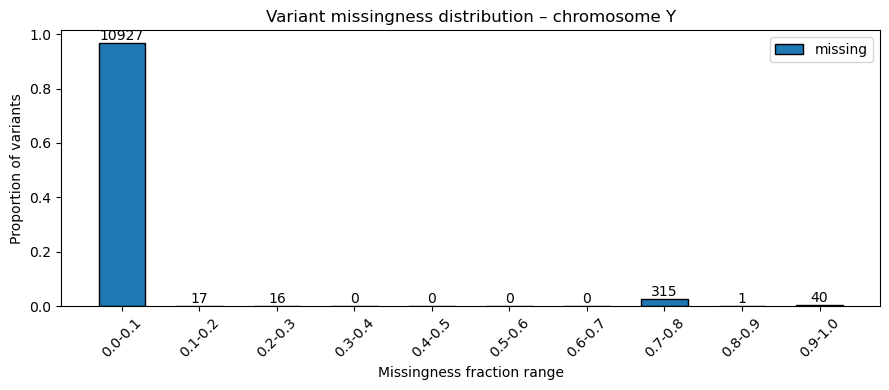

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (6,) and arg 1 with shape (5,).

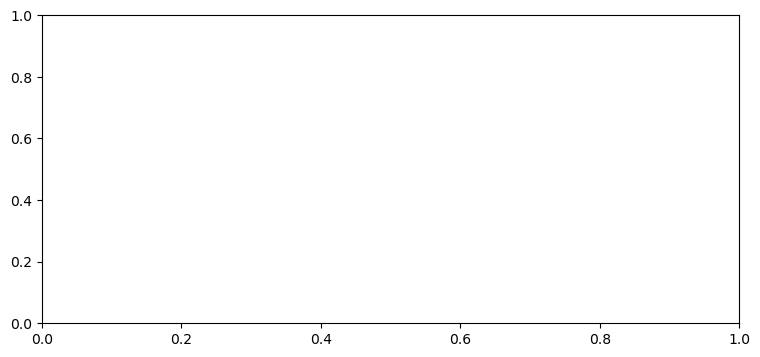

In [9]:
# Chromosomes to process and output directory for figures
CHROMS = list(range(1, 23)) + ["X", "Y"]
CHROMS = [13, 18] + ["X", "Y"]
CHROMS = ["Y"]
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Loop over chromosomes: run variant_missingness_distribution, save figures, collect summary
summary_list = []
for chrom in CHROMS:
    sample_map = pd.read_csv(f"{DIR}/bgen/ch{chrom}/c{chrom}_b0_v1_samples.csv")
    sample_map = sample_map.rename(columns = {"ID_1": "eid"})
    save_prefix = os.path.join(FIG_DIR, f"ch{chrom}")
    s = variant_missingness_distribution(chrom, save_prefix=save_prefix)
    summary_list.append(s)

summary_df = pd.concat(summary_list, ignore_index=True) if summary_list else pd.DataFrame()
summary_df

In [ ]:
# Combined plot: aggregate summary_df by (bin_left, bin_right)
# n_variants_combined = sum of n_variants per bucket across chroms
# Weighted average: (n * prop).sum() / n_variants_combined for each proportion
if len(summary_df) == 0:
    raise ValueError("summary_df is empty; run the chromosome loop first.")

gb = summary_df.groupby(["bin_left", "bin_right"])
combined = gb.agg(n_variants=("n_variants", "sum")).reset_index()

def weighted_avg(g):
    n = g["n_variants"].sum()
    if n == 0:
        return np.nan
    return (g["n_variants"] * g["prop_variants_missing"]).sum() / n

combined["prop_variants_missing"] = gb.apply(weighted_avg).values
combined["prop_variants_one_mut"] = gb.apply(
    lambda g: (g["n_variants"] * g["prop_variants_one_mut"]).sum() / g["n_variants"].sum()
).values
# For two_mut, Y has NaN; weight only by chroms that have two_mut (exclude Y)
def two_mut_weighted(g):
    ok = g["prop_variants_two_mut"].notna()
    if ok.sum() == 0:
        return np.nan
    n = g.loc[ok, "n_variants"]
    p = g.loc[ok, "prop_variants_two_mut"]
    return (n * p).sum() / n.sum()
combined["prop_variants_two_mut"] = gb.apply(two_mut_weighted).values

x = np.arange(len(combined))
width = 0.6
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(x, combined["prop_variants_missing"], width, label="missing", edgecolor="k")
ax.bar_label(bars, labels=combined["n_variants"].astype(int))
ax.set_xlabel("Missingness fraction range")
ax.set_ylabel("Proportion of variants (weighted avg)")
ax.set_title("Variant missingness distribution – genome-wide (all chromosomes combined)")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{combined['bin_left'].iloc[i]:.1f}-{combined['bin_right'].iloc[i]:.1f}" for i in range(len(combined))],
    rotation=45,
)
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "combined_missingness.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from collections import defaultdict

def sample_missingness_distribution(chrom):
    files = sorted(
        glob.glob(f"{DIR}bgen/ch{chrom}/c{chrom}_b0_*parquet")
    )
    sample_counts = defaultdict(lambda: [0, 0])  # eid -> [missing, total]

    for path in files:
        df = clean_chrom(path, chrom)
        X = df.loc[:, df.columns.str.startswith(f"c{chrom}_")]

        if X.shape[1] == 0 or len(df) == 0:
            del df, X
            gc.collect()
            continue

        missing_per_sample = X.isna().sum(axis=1).to_numpy()
        total_per_sample = X.shape[1]

        for eid, miss in zip(df["eid"].to_numpy(), missing_per_sample):
            m, t = sample_counts[eid]
            sample_counts[eid] = [m + miss, t + total_per_sample]

        del df, X
        gc.collect()

    if not sample_counts:
        print("No data after filtering on eids.")
        return None

    fracs = np.array([m / t for (m, t) in sample_counts.values()])

    plt.figure(figsize=(7, 4))
    plt.hist(fracs, bins=np.linspace(0, 1, 21), edgecolor="k")
    plt.xlabel("Sample missingness fraction")
    plt.ylabel("Number of individuals")
    plt.title(f"Per‑sample missingness – chromosome {chrom}")
    plt.tight_layout()
    plt.show()

    return fracs

In [ ]:
sample_fracs = sample_missingness_distribution("Y")